# Demo

This demo walks through:
1. Making a layer/gate set for an IBM device.
2. Creating a 2-local Pauli-Lindblad model based on the device topology.
3. Build "vanilla" Pauli-Lindblad learning experiments.
4. Running the experiments.
5. Fitting the model and getting noise maps.

In [1]:
import numpy as np
import qiskit.quantum_info as qi
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeFez

from qiskit_noise_learning.aer_executor import AerExecutor

backend = FakeFez()

## 1. Build a gate set with a single layer on a ring of qubits

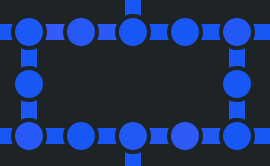

In [2]:
from qiskit_noise_learning.gate_sets import QiskitGateSet

qubit_subset = [*range(25, 30), *range(37, 39), *range(45, 50)]
gate_set = QiskitGateSet(backend.num_qubits, target=backend.target, qubit_subset=qubit_subset)

layer_1_pairs = [(25, 26), (27, 28), (29, 38), (37, 45), (46, 47), (48, 49)]

with gate_set.build_new_gate("layer_1") as builder:
    for pair in layer_1_pairs:
        builder.circuit.cz(*pair)

gate_set.draw()

## 2. Create a 2-local Pauli-Lindblad model.

In [3]:
from qiskit_noise_learning.models import PauliLindbladModel

true_pauli_lindblad_model = PauliLindbladModel.k_local(gate_set, k=3, noise_site={"layer_1": "after"})

# Neglecting SPAM for now:
true_pauli_lindblad_model.generators["M"] = qi.QubitSparsePauliList.empty(
    true_pauli_lindblad_model.gate_set.num_qubits
)
true_pauli_lindblad_model.generators["P"] = qi.QubitSparsePauliList.empty(
    true_pauli_lindblad_model.gate_set.num_qubits
)

true_pauli_lindblad_model.generators

{'M': <QubitSparsePauliList with 0 elements on 156 qubits: []>,
 'P': <QubitSparsePauliList with 0 elements on 156 qubits: []>,
 'layer_1': <QubitSparsePauliList with 468 elements on 156 qubits: [Z_25, X_25, Y_25, Z_26, X_26, Y_26, Z_27, X_27, Y_27, Z_28, X_28, Y_28, Z_29, X_29, Y_29, Z_38, X_38, Y_38, Z_37, X_37, Y_37, Z_45, X_45, Y_45, Z_46, X_46, Y_46, Z_47, X_47, Y_47, Z_48, X_48, Y_48, Z_49, X_49, Y_49, Z_26 Z_25, Z_26 X_25, Z_26 Y_25, X_26 Z_25, X_26 X_25, X_26 Y_25, Y_26 Z_25, Y_26 X_25, Y_26 Y_25, Z_37 Z_25, Z_37 X_25, Z_37 Y_25, X_37 Z_25, X_37 X_25, X_37 Y_25, Y_37 Z_25, Y_37 X_25, Y_37 Y_25, Z_27 Z_26, Z_27 X_26, Z_27 Y_26, X_27 Z_26, X_27 X_26, X_27 Y_26, Y_27 Z_26, Y_27 X_26, Y_27 Y_26, Z_28 Z_27, Z_28 X_27, Z_28 Y_27, X_28 Z_27, X_28 X_27, X_28 Y_27, Y_28 Z_27, Y_28 X_27, Y_28 Y_27, Z_29 Z_28, Z_29 X_28, Z_29 Y_28, X_29 Z_28, X_29 X_28, X_29 Y_28, Y_29 Z_28, Y_29 X_28, Y_29 Y_28, Z_38 Z_29, Z_38 X_29, Z_38 Y_29, X_38 Z_29, X_38 X_29, X_38 Y_29, Y_38 Z_29, Y_38 X_29, Y_38 

## 3. Build learning experiments

In [4]:
from qiskit_noise_learning.experiment_builder import (
    BindSequenceDepths,
    CompleteSequences,
    Depth1Paths,
    EvenDepthPaths,
    Experiment,
    EvenDepthVanillaPaths,
    GenerateInstructionSequences,
    IdentifyRelations,
    MergeInstructionSequences,
    RankReducePaths,
)

pauli_lindblad_model = PauliLindbladModel.k_local(gate_set, k=2, noise_site={"layer_1": "after"})

# Neglecting SPAM for now:
pauli_lindblad_model.generators["M"] = qi.QubitSparsePauliList.empty(
    pauli_lindblad_model.gate_set.num_qubits
)
pauli_lindblad_model.generators["P"] = qi.QubitSparsePauliList.empty(
    pauli_lindblad_model.gate_set.num_qubits
)

# experiment = Experiment(fidelity_model=pauli_lindblad_model, shots=20, randomizations=50)
experiment = Experiment(fidelity_model=pauli_lindblad_model, shots=2**14, randomizations=1)  # 50)

experiment_builder = (
    # add paths
    #EvenDepthVanillaPaths()
    EvenDepthPaths()
    + Depth1Paths()
    + RankReducePaths()
    #EvenDepthVanillaPaths()
    # add instruction sequences measuring 9 bases
    # + VanillaInstructionSequences()
    #+ GenerateInstructionSequences()
    #+ MergeInstructionSequences()
    # relate them to the paths, and complete them
    #+ IdentifyRelations()
    #+ CompleteSequences()
    # set numerical parameters
    # + BindSequenceDepths([0, 2, 16, 32, 64, 128])
    #+ BindSequenceDepths([1, 2, 16, 32, 64, 128])
)

experiment = experiment_builder.run(experiment)
print(experiment)

Experiment:
  Fidelity model: <qiskit_noise_learning.models.pauli_lindblad_model.PauliLindbladModel object at 0x116ff6710>
  Paths: 144 (132 unbound, 12 bound)
  Instruction sequences: None
  Relations: None
  Shots: 16384
  Randomizations: 1
  Randomization multipliers: None


# 4. Build random model data and `AveragedData` directly without simulation

In [46]:
from qiskit_noise_learning.models.pauli_lindblad_model import GeneratorIndex
from qiskit_noise_learning.data import ModelData, AveragedData

# should have a method for generating random model data?

generator_indices = []
rand_rates = []
for gate in true_pauli_lindblad_model.gate_set:
    for generator in true_pauli_lindblad_model.generators[gate]:
        generator_indices.append(GeneratorIndex(gate, generator))
        if len(generator.indices) < 3:
            rand_rates.append(1e-4* np.random.random())
        else:
            rand_rates.append(1e-3* np.random.random())

true_model_data = ModelData.from_arrays(
    parameter_indices=generator_indices,
    parameter_values=rand_rates,
    covariance=np.zeros((len(generator_indices),)*2, dtype=float),
    time_lbs=np.empty(len(generator_indices), dtype="datetime64[us]"),
    time_ubs=np.empty(len(generator_indices), dtype="datetime64[us]"),
)

In [47]:
unbound_paths = []
depths = []
observables = []
std = []

for path in experiment.paths:
    unbound_paths.append(path.without_depth())
    depths.append(path.depth if path.depth is not None else -1)
    observables.append(true_pauli_lindblad_model.fidelity_estimate(path, true_model_data))
    std.append(0.)

true_averaged_data = AveragedData.from_arrays(
    unbound_paths=unbound_paths,
    depths=depths,
    observables=observables,
    std=std,
    time_lbs=np.empty(len(observables), dtype="datetime64[us]"),
    time_ubs=np.empty(len(observables), dtype="datetime64[us]"),
)

# 5. Run model solve stage

In [48]:
from qiskit_noise_learning.analysis import NNLSSolve, Fit, LegacySolve

fit = Fit(model=pauli_lindblad_model)
fit[AveragedData] = true_averaged_data

fit = NNLSSolve().run(fit)
#fit = LegacySolve().run(fit)

In [49]:
fit_rates = fit.model_data.dataset.parameter_values.data
fit_generators = fit.model_data.dataset.parameter.data

true_parameter_indices = list(true_model_data.dataset.parameter.data)
true_rates = np.empty_like(fit_rates)
for gen_idx, generator in enumerate(fit_generators):
    true_idx = true_parameter_indices.index(generator)
    true_rates[gen_idx] = true_model_data.dataset.parameter_values.data[true_idx]

In [50]:
np.max(np.abs(fit_rates - true_rates))

np.float64(0.004561918158535878)

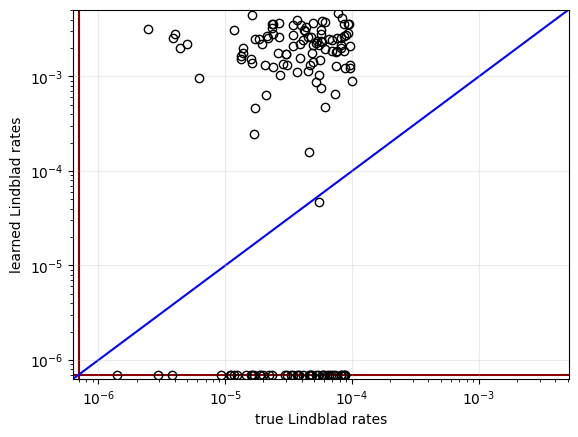

In [51]:
from matplotlib import pyplot as plt

learned_vs_true = np.array(
    [true_rates, fit_rates]
)

epsilon = min(learned_vs_true[learned_vs_true > 0]) / 2.0
learned_vs_true[learned_vs_true == 0] = epsilon
lims = (np.min(learned_vs_true) * 0.9, np.max(learned_vs_true) * 1.1)
plt.loglog(learned_vs_true[0], learned_vs_true[1], ls="", marker="o", color="black", mfc="none")
plt.axvline(epsilon, color="darkred", zorder=-1)
plt.axhline(epsilon, color="darkred", zorder=-1)
plt.plot(lims, lims, color="blue", zorder=-1)
plt.ylim(lims)
plt.xlim(lims)
plt.xlabel("true Lindblad rates")
plt.ylabel("learned Lindblad rates")
plt.grid(alpha=0.25)
plt.show()

In [52]:
unbound_paths = []
depths = []
observables = []
std = []

for path in experiment.paths:
    unbound_paths.append(path.without_depth())
    depths.append(path.depth if path.depth is not None else -1)
    observables.append(pauli_lindblad_model.fidelity_estimate(path, fit.model_data))
    std.append(0.)

fit_averaged_data = AveragedData.from_arrays(
    unbound_paths=unbound_paths,
    depths=depths,
    observables=observables,
    std=std,
    time_lbs=np.empty(len(observables), dtype="datetime64[us]"),
    time_ubs=np.empty(len(observables), dtype="datetime64[us]"),
)

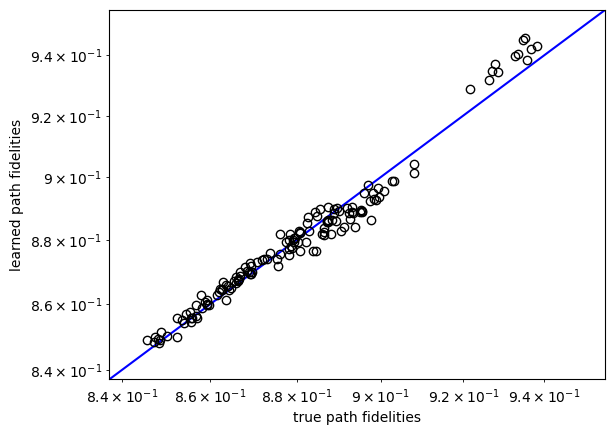

In [53]:
from matplotlib import pyplot as plt

learned_vs_true = np.array(
    [fit_averaged_data.dataset["observables"].data, 
     true_averaged_data.dataset["observables"].data]
)

epsilon = min(learned_vs_true[learned_vs_true > 0]) / 2.0
learned_vs_true[learned_vs_true == 0] = epsilon
lims = (np.min(learned_vs_true) * 0.99, np.max(learned_vs_true) * 1.01)
plt.loglog(learned_vs_true[0], learned_vs_true[1], ls="", marker="o", color="black", mfc="none")
plt.axvline(epsilon, color="darkred", zorder=-1)
plt.axhline(epsilon, color="darkred", zorder=-1)
plt.plot(lims, lims, color="blue", zorder=-1)
plt.ylim(lims)
plt.xlim(lims)
plt.xlabel("true path fidelities")
plt.ylabel("learned path fidelities")
plt.grid(alpha=0.25)
plt.show()